# 🔁 Practice Notebook — Day 1 Review
**Goal:** Repeat what you learned today with a NEW dataset (Pokemon stats).  
The structure is similar to FIFA so your brain can see the same patterns.

**Dataset:** `pokemon_practice.csv` (50 Pokemon × 23 columns)

**Rules:**
- Read the question in the markdown cell
- Write code and answer in the empty code/markdown cell below
- Do NOT look at your FIFA notebook — try from memory first
- If you get stuck for 15 min, open FIFA notebook as hint


## Setup
Import pandas and matplotlib, then load the dataset.

In [2]:
import pandas as pd



df = pd.read_csv('pokemon_practice.csv')
df.head()


,id,name,types,hp,attack,defense,sp_attack,sp_defense,speed,total_score,...,trainer_id,region,captured_date,joined_team_date,phys_rating,spec_rating,def_rating,legendary_bonus,shiny_version,evolution_from
0,1000,Pikachu,Electric,132.0,81.0,122.0,44,136,91,606,...,NaN,Kanto,2021-08-12,NaN,60+1,58+2,50+3,NaN,NaN,NaN
1,1001,Charizard,"Fire, Flying",87.0,51.0,137.0,118,78,78,549,...,T113,Kanto,2021-01-12,2022-07-18,81+3,55+2,83+3,NaN,NaN,NaN
2,1002,Bulbasaur,"Grass, Poison",159.0,113.0,121.0,140,89,27,649,...,T369,Hoenn,2021-02-15,2022-04-27,86+2,53+0,75-3,NaN,NaN,NaN
3,1003,Squirtle,Water,69.0,114.0,109.0,111,82,43,528,...,T692,Hoenn,2021-01-16,2022-01-21,65+0,84+0,68+0,NaN,NaN,Pichu
4,1004,Mewtwo,Psychic,NaN,NaN,NaN,70,57,91,519,...,T602,Hoenn,2021-03-12,2022-05-24,51+1,72+4,74+1,NaN,NaN,NaN


# Part 1 — Dataset Introduction

This is the same as FIFA Task 1. Get familiar with the data first.

### Q1: How many rows and columns are in this dataset?
Use `.shape`.

In [3]:
df.shape

(50, 23)

### Q2: Print all column names as a list.
Which method returns a Python list of all columns?

In [4]:
df.columns

Index(['id', 'name', 'types', 'hp', 'attack', 'defense', 'sp_attack',
       'sp_defense', 'speed', 'total_score', 'potential', 'rarity_level',
       'value_coins', 'trainer_id', 'region', 'captured_date',
       'joined_team_date', 'phys_rating', 'spec_rating', 'def_rating',
       'legendary_bonus', 'shiny_version', 'evolution_from'],
      dtype='object')

### Q3: Show the first 3 rows AND a random sample of 3 rows.
Why do we use both `head()` and `sample()` instead of only one?

**My answer (write in this same cell after the code):**
*[your answer here]*

In [5]:
print(df.head())
print(df.sample(3))

     id       name          types     hp  attack  defense  sp_attack  \
0  1000    Pikachu       Electric  132.0    81.0    122.0         44   
1  1001  Charizard   Fire, Flying   87.0    51.0    137.0        118   
2  1002  Bulbasaur  Grass, Poison  159.0   113.0    121.0        140   
3  1003   Squirtle          Water   69.0   114.0    109.0        111   
4  1004     Mewtwo        Psychic    NaN     NaN      NaN         70   

   sp_defense  speed  total_score  ...  trainer_id region  captured_date  \
0         136     91          606  ...         NaN  Kanto     2021-08-12   
1          78     78          549  ...        T113  Kanto     2021-01-12   
2          89     27          649  ...        T369  Hoenn     2021-02-15   
3          82     43          528  ...        T692  Hoenn     2021-01-16   
4          57     91          519  ...        T602  Hoenn     2021-03-12   

  joined_team_date phys_rating spec_rating def_rating legendary_bonus  \
0              NaN        60+1       

### Q4: Run `df.info()` and check dtypes.
Which columns are `object` type? List 3 examples.

**My answer:**
*[write here]*

In [6]:
object_col = [x for x in df.columns if df[x].dtype == 'object']
print(object_col)

['name', 'types', 'rarity_level', 'trainer_id', 'region', 'captured_date', 'joined_team_date', 'phys_rating', 'spec_rating', 'def_rating', 'evolution_from']


### Q5: Find all columns that start with `sp_` using list comprehension.
Hint: `[c for c in df.columns if c.startswith(...)]`

In [7]:
include_sp = [c for c in df.columns if c.startswith('sp_')]
print(include_sp)

['sp_attack', 'sp_defense']


### Q6: Find all columns that END with `_date`.
Hint: use `.endswith()` this time.

In [8]:
include_date = [c for c in df.columns if c.endswith('_date')]
print(include_date)

['captured_date', 'joined_team_date']


# Part 2 — Missing Value Analysis

Same as FIFA Task 2. Find which columns have missing data and decide what to do.

### Q7: Build a `missing_df` DataFrame with two columns: `missing_count` and `missing_pct`.
Sort by count descending, and show only columns with at least 1 null.

**Remember:** Use dictionary style `pd.DataFrame({...})`, NOT empty DataFrame + loop.

In [9]:
missing_df = pd.DataFrame()
missing_df["missing_count"]= df.isnull().sum()
missing_df["missing_pct"]= missing_df["missing_count"]/df.shape[0]*100
missing_df= missing_df.sort_values(by=['missing_count'], ascending=False)
missing_df= missing_df[missing_df["missing_count"]>0]
missing_df

,missing_count,missing_pct
shiny_version,50,100.0
legendary_bonus,50,100.0
evolution_from,32,64.0
trainer_id,15,30.0
joined_team_date,6,12.0
hp,4,8.0
attack,4,8.0
defense,4,8.0


### Q8: Which columns are 100% null?
Use list comprehension with `.isnull().all()`.

**My answer:**
*[list the columns you found]*

In [56]:
##YANLIŞŞ
all_null_col= [x for x in missing_df.columns if missing_df[x].isnull().all()]
all_null_col
## DOĞRU
all_null_col = [c for c in df.columns if df[c].isnull().all()]
all_null_col


['legendary_bonus', 'shiny_version']

### Q9: Four Pokemon have missing `hp`, `attack`, and `defense` values.  
Find out WHO they are. (Hint: filter where `hp` is null, then look at `name` column.)

**My answer — who are they and what do they have in common?**
*[your answer here]*

In [11]:
df[df["hp"].isnull()]

,id,name,types,hp,attack,defense,sp_attack,sp_defense,speed,total_score,...,trainer_id,region,captured_date,joined_team_date,phys_rating,spec_rating,def_rating,legendary_bonus,shiny_version,evolution_from
4,1004,Mewtwo,Psychic,NaN,NaN,NaN,70,57,91,519,...,T602,Hoenn,2021-03-12,2022-05-24,51+1,72+4,74+1,NaN,NaN,NaN
17,1017,Articuno,"Ice, Flying",NaN,NaN,NaN,62,123,120,616,...,T596,Sinnoh,2021-02-10,2022-05-13,62+1,49+4,75-2,NaN,NaN,Ivysaur
18,1018,Zapdos,"Electric, Flying",NaN,NaN,NaN,130,41,86,534,...,T189,Johto,2021-04-23,NaN,40+0,79+1,82-0,NaN,NaN,NaN
19,1019,Moltres,"Fire, Flying",NaN,NaN,NaN,87,138,94,633,...,T762,Kanto,2021-08-12,2022-08-13,68+3,64+4,75-0,NaN,NaN,NaN


### Q10: Confirm your hypothesis.
Count the Pokemon with missing `hp` and compare with the count of Pokemon you identified in Q9. They should match.

**Mentor reminder:** Use `.isnull().sum()` to count nulls, NOT `.count()` — `.count()` counts NON-null values!

In [12]:
a = df["hp"].isnull().sum()
b = len(df[df["hp"].isnull()])
bool(a==b)




True

### Q11: Decision — Drop, Fill, or Keep?

For each problematic column, decide what to do. Write your plan in this cell.

| Column | Strategy | Why      |
|--------|----------|----------|
| legendary_bonus | drop     | all null |
| shiny_version | drop     | all null |
| trainer_id | fill     |          |
| evolution_from | fill     |          |
| hp, attack, defense | fill     | median   |


# Part 3 — Data Type Fixes

Same as FIFA Task 3. Convert wrong dtypes so we can use columns later.

### Q12: Inspect `phys_rating`, `spec_rating`, `def_rating`.
What format are they in? Look at first 5 rows.

In [13]:
print(df["phys_rating"][0])
print(df["spec_rating"].loc[0:2])
print(df["def_rating"].loc[0])

ratings = df[["phys_rating","spec_rating","def_rating"]]



60+1
0    58+2
1    55+2
2    53+0
Name: spec_rating, dtype: object
50+3


### Q13: Mini investigation — do any ratings contain `-` (minus)?
Use `.str.contains('-', na=False).sum()` on each of the 3 rating columns.

**My answer:**
*[which columns have minus values?]*

In [18]:
print(df["phys_rating"].str.contains("-",na=False).sum())
print(df["spec_rating"].str.contains("-",na=False).sum())
print(df["def_rating"].str.contains("-",na=False).sum())


0
0
19


### Q14: Parse the ratings to integers.
Remember: if there's a `-` in the data, you MUST use regex, not `.str.split('+')`.

Write code to convert all 3 rating columns to int using a loop + regex.

In [42]:
for x in ratings.columns:
    df[x]=df[x].str.extract(r'(\d+)').astype(int)


### Q15: Verify your Q14 worked.
Print dtypes of the 3 rating columns — all should be `int`.

In [43]:
for x in ratings.columns:
     print(df[x].dtypes)
     print(df[x].iloc[2])

int64
86
int64
53
int64
75


### Q16: Convert `captured_date` to datetime.
This column has NO nulls, so you don't need `errors='coerce'`.

In [46]:
df["captured_date"]= pd.to_datetime(df["captured_date"])
df["captured_date"].dtype


dtype('<M8[ns]')

### Q17: Convert `joined_team_date` to datetime.
This column HAS nulls. What parameter must you use to avoid errors?

**My answer — why did we need that parameter here but not in Q16?**
*[write here]*

In [52]:
df["joined_team_date"].dtypes
df["joined_team_date"]= pd.to_datetime(df["joined_team_date"],errors='coerce')
df["joined_team_date"].dtypes



dtype('<M8[ns]')

# Part 4 — Quick Visualization

Like the bar chart in FIFA Task 2.

### Q18: Make a horizontal bar chart of the top 10 columns with most missing values (in %).
Use `plt.figure(figsize=(10,5))`, `plt.barh()`, and proper labels.

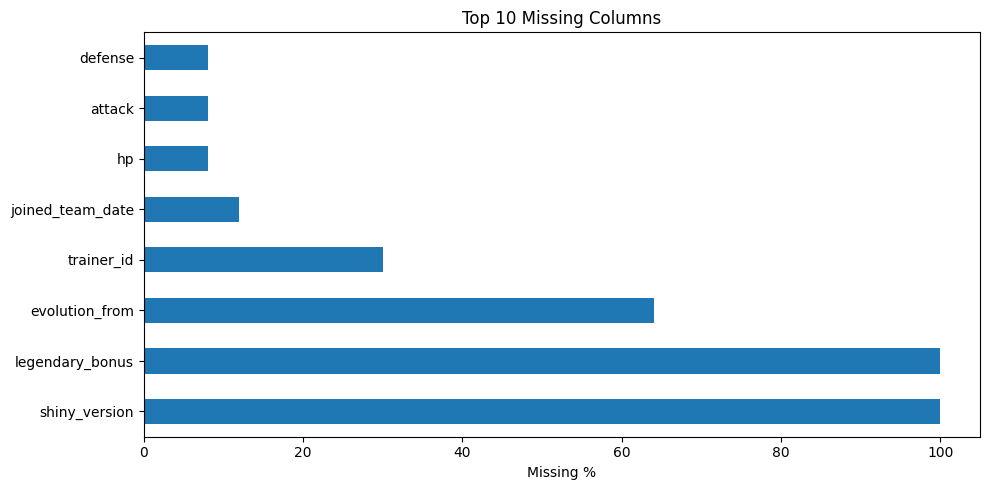

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
missing_df.head(10).plot(kind="barh", y="missing_pct", legend=False, ax=plt.gca())
plt.xlabel("Missing %")
plt.title("Top 10 Missing Columns")
plt.tight_layout()
plt.show()


# 🏁 Closing Reflection

### Q19: What was EASIER today compared to yesterday?
*[write here]*

### Q20: What is one concept that is still confusing?
*[be honest — this helps your mentor know what to review]*

### Q21: Without looking at your notes — explain in 2 sentences:
**What does `df['col'].str.extract(r'(\d+)')` do?**

*[write in your own words]*
